In [1]:
# 1. Установка и импорт библиотек
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены")

Библиотеки загружены


In [16]:
csv_path = r"../lab4/dataset2/all_letters_info.csv"
img_dir = r"../lab4/dataset2//all_letters_image/all_letters_image"
df = pd.read_csv(csv_path)

In [17]:
label_encoder = LabelEncoder()
y_labels = label_encoder.fit_transform(df['letter']) 
num_classes = len(label_encoder.classes_)
print("Классы:", label_encoder.classes_)
print("Всего классов:", num_classes)

image_size = 32
X_images = []
failed = 0

for idx, row in df.iterrows():
    img_path = os.path.join(img_dir, row['file'])
    img = Image.open(img_path).convert('RGB')
    img = img.resize((image_size, image_size))
    img_array = np.array(img) / 255.0
    X_images.append(img_array)
        
X = np.array(X_images)
y = keras.utils.to_categorical(y_labels, num_classes)

print(f"Загружено изображений: {X.shape}, пропущено: {failed}")
print(f"Размерность X: {X.shape} (число, высота, ширина, каналы)")

Классы: ['а' 'б' 'в' 'г' 'д' 'е' 'ж' 'з' 'и' 'й' 'к' 'л' 'м' 'н' 'о' 'п' 'р' 'с'
 'т' 'у' 'ф' 'х' 'ц' 'ч' 'ш' 'щ' 'ъ' 'ы' 'ь' 'э' 'ю' 'я' 'ё']
Всего классов: 33
Загружено изображений: (14190, 32, 32, 3), пропущено: 0
Размерность X: (14190, 32, 32, 3) (число, высота, ширина, каналы)


In [18]:
# 4. Разделение на train/val/test (80/10/10)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (11352, 32, 32, 3), Val: (1419, 32, 32, 3), Test: (1419, 32, 32, 3)


In [19]:
# 5. Построение модели CNN
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(image_size, image_size, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 33)                  │           8,481 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 233,057 (910.38 KB)

 Trainable params: 233,057 (910.38 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 6. Обучение модели
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.0388 - loss: 3.4594 - val_accuracy: 0.0423 - val_loss: 3.3806
Epoch 2/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0597 - loss: 3.3646 - val_accuracy: 0.0726 - val_loss: 3.3191
Epoch 3/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1464 - loss: 3.0277 - val_accuracy: 0.2671 - val_loss: 2.5561
Epoch 4/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2934 - loss: 2.4127 - val_accuracy: 0.4073 - val_loss: 2.0698
Epoch 5/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3879 - loss: 2.0719 - val_accuracy: 0.4848 - val_loss: 1.7965
Epoch 6/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4693 - loss: 1.7929 - val_accuracy: 0.5736 - val_loss: 1.5176
Epoch 7/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5264 - loss: 1.6164 - val_accuracy: 0.6286 - val_loss: 1.2997
Epoch 8/30
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5710 - loss: 1.4482 - val_accuracy: 0.

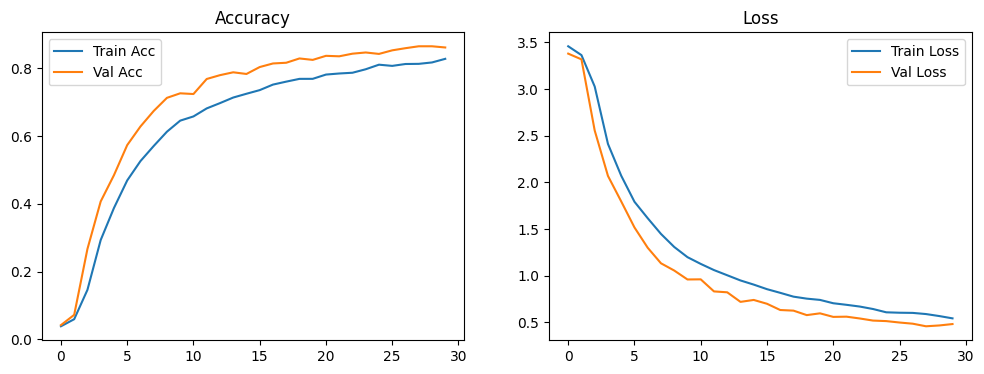

In [8]:
# 7. Визуализация обучения
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [9]:
# 8. Оценка на тестовой выборке
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Точность на тестовых данных: {test_acc:.4f}")

Точность на тестовых данных: 0.8450


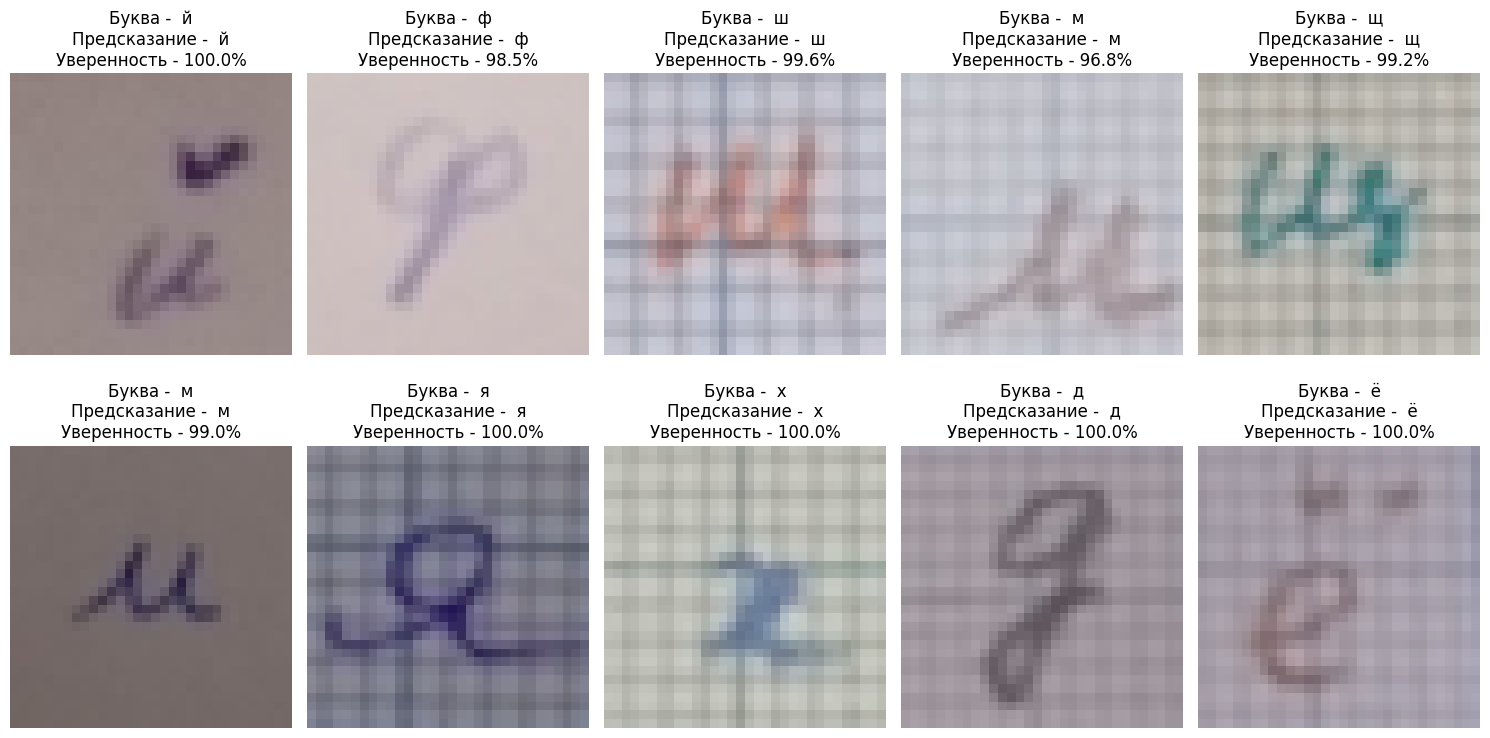

In [12]:
# 9. Функция предсказания (буква + уверенность)
def predict_letter(image_array, model, label_encoder):
    """
    Принимает: image_array - numpy массив (32,32,3) или (1,32,32,3)
    Возвращает: предсказанную букву, уверенность (max вероятность)
    """
    if image_array.ndim == 3:
        image_array = np.expand_dims(image_array, axis=0)
    probs = model.predict(image_array, verbose=0)[0]
    max_prob = np.max(probs)
    pred_class = np.argmax(probs)
    pred_letter = label_encoder.inverse_transform([pred_class])[0]
    confidence = max_prob * 100
    return pred_letter, confidence

# Вывод 10 случайных изображений из тестовой выборки
n_samples = 10
indices = np.random.choice(len(X_test), n_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    sample_img = X_test[idx]
    true_label = label_encoder.inverse_transform([np.argmax(y_test[idx])])[0]
    pred_letter, conf = predict_letter(sample_img, model, label_encoder)
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_img)
    plt.title(f"Буква -  {true_label}\nПредсказание -  {pred_letter}\nУверенность - {conf:.1f}%")
    plt.axis('off')

plt.tight_layout()
plt.show()